# Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from dtreeviz import *

import warnings
warnings.filterwarnings('ignore')

# Decison Tree Classifier

## Load the dataset

In [2]:
X_clf, y_clf = load_iris(return_X_y=True, as_frame=True)
feature_names_clf = list(X_clf.columns)
target_names_clf = ["setosa", "versicolor", "virginica"]

## Train test split

In [3]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

In [4]:
X_train_clf.shape, X_test_clf.shape, y_train_clf.shape, y_test_clf.shape

((120, 4), (30, 4), (120,), (30,))

## Fit the model

In [5]:
clf = DecisionTreeClassifier(max_depth=3)

In [6]:
clf.fit(X_train_clf, y_train_clf)

DecisionTreeClassifier(max_depth=3)

## Visualize tree

### Using sklearn's plot_tree

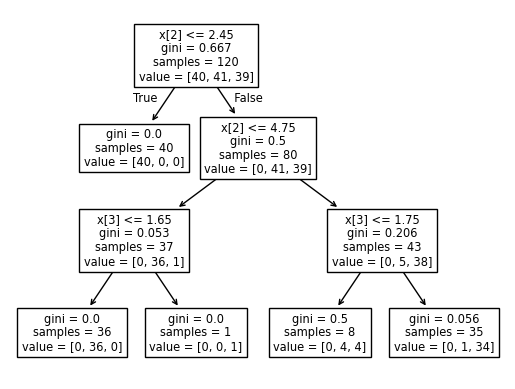

In [7]:
plot_tree(clf);

* The main issue with plot_tree() is that it does not specify the name of the column/feature on which the split has happened rather it gives you the index of that column/feature which makes the interpretation difficult.

### Using dtreeviz

In [8]:
feature_names_clf

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


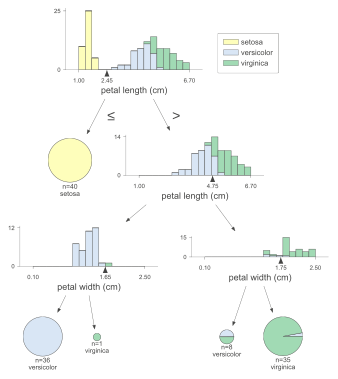

In [9]:
clf_viz = model(clf, 
                X_train_clf, 
                y_train_clf, 
                feature_names=feature_names_clf, 
                class_names=target_names_clf)
clf_viz.view(scale=1)

- scale - increase/decrease the image size

# Decison Tree Regressor

## Load the dataset

In [10]:
X_reg, y_reg = load_diabetes(return_X_y=True, as_frame=True)
feature_names_reg = list(X_reg.columns)
target_names_reg = ['disease_progression']

## Train test split

In [11]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [12]:
X_train_reg.shape, X_test_reg.shape, y_train_reg.shape, y_test_reg.shape

((353, 10), (89, 10), (353,), (89,))

## Fit the model

In [13]:
reg = DecisionTreeRegressor(max_depth=2)

In [14]:
reg.fit(X_train_reg, y_train_reg)

DecisionTreeRegressor(max_depth=2)

## Visualize the tree

### Using sklearn's plot_tree

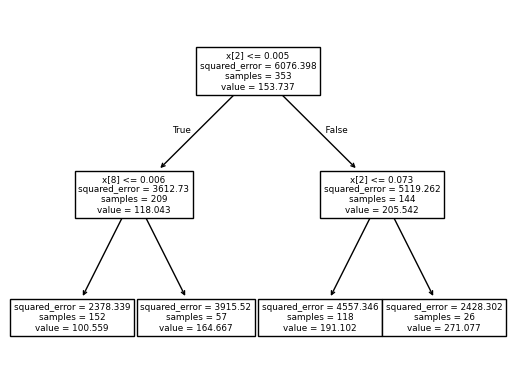

In [15]:
plot_tree(reg);

### Using dtreeviz

In [16]:
feature_names_reg

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

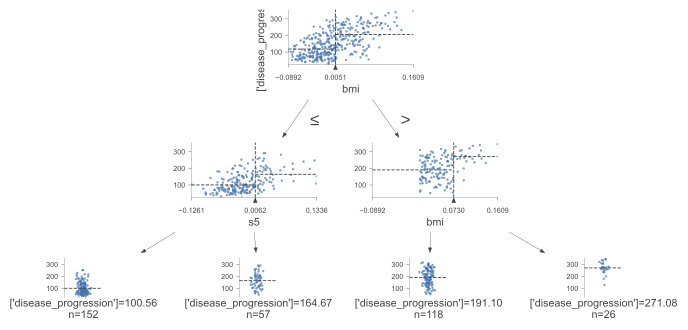

In [17]:
reg_viz = model(reg,
               X_train_reg, 
               y_train_reg, 
               feature_names=feature_names_reg, 
               target_name=target_names_reg)
reg_viz.view(scale=1.2)

- Main difference b/w plotting the dtreeviz for classification and regression is that - for classification you'll have the histogram and for regression you'll have scatter plot and splits will be shown on it.

# Some variations in Dtreeviz

## Orientation of the tree

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


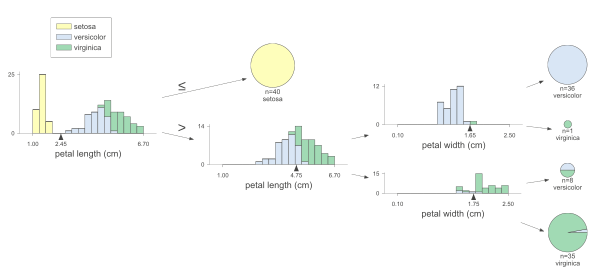

In [18]:
clf_viz.view(orientation='LR')

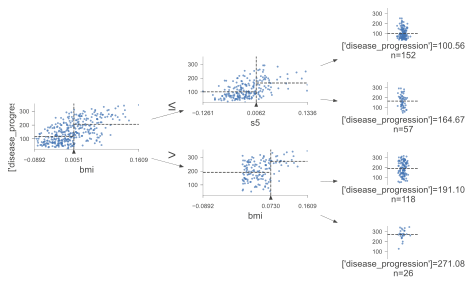

In [19]:
reg_viz.view(orientation='LR') # LR - left to Right

## Prediction Path

In [20]:
test_point_clf = np.array([6.2, 3.50, 8.6, 4.2])

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


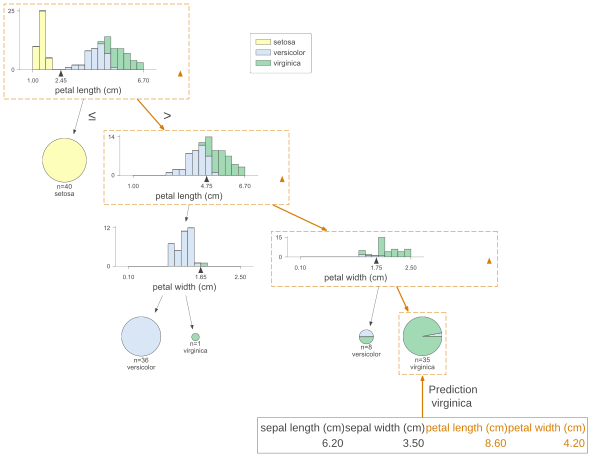

In [21]:
clf_viz.view(x=test_point_clf)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


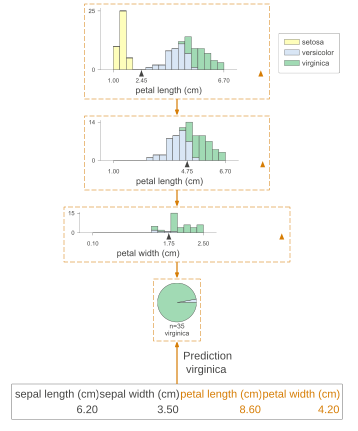

In [22]:
clf_viz.view(x=test_point_clf, show_just_path=True)

## Show Node Number

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


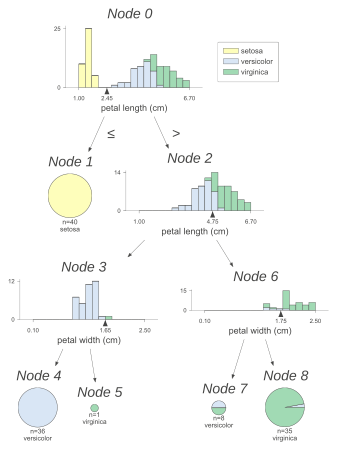

In [23]:
clf_viz.view(show_node_labels=True)

## Without graphs

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


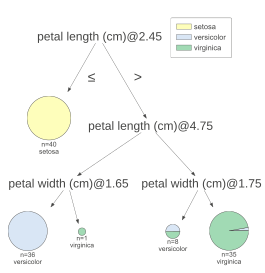

In [24]:
clf_viz.view(fancy=False)

## Prediction path in words

In [30]:
print(explain_prediction_path(
    clf, 
    test_point_clf,
    X_train_clf,
    y_train_clf,
    explanation_type='plain_english',
    feature_names=feature_names_clf,
    target_name=target_names_clf
))

4.75 <= petal length (cm) 
1.75 <= petal width (cm) 



## Feature Importance

None


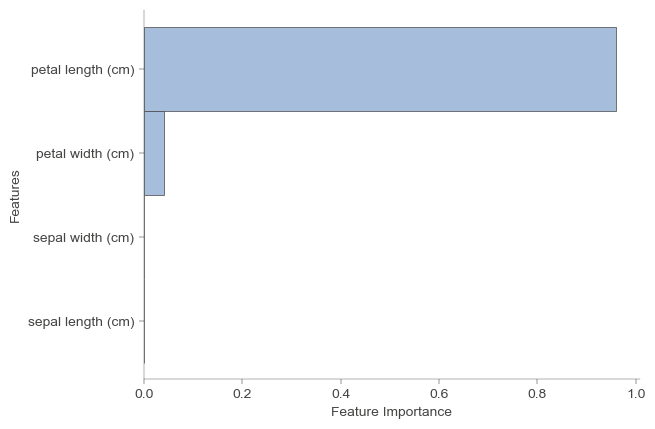

In [31]:
print(explain_prediction_path(
    clf, 
    test_point_clf,
    X_train_clf,
    y_train_clf,
    explanation_type='sklearn_default',
    feature_names=feature_names_clf,
    target_name=target_names_clf
))